Build a regression model.

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
conn = sqlite3.connect("bike_stations.db")
df = pd.read_sql("SELECT * FROM bike_data", conn)
conn.close()

In [5]:
features = ["Distance", "Rating", "Latitude", "Longitude"]
target = "Free Bikes"

In [6]:
df = df[features + [target]].dropna()

In [7]:
X = df[features]
y = df[target]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

Provide model output and an interpretation of the results. 

In [13]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error: 67.56
R² Score: 0.01


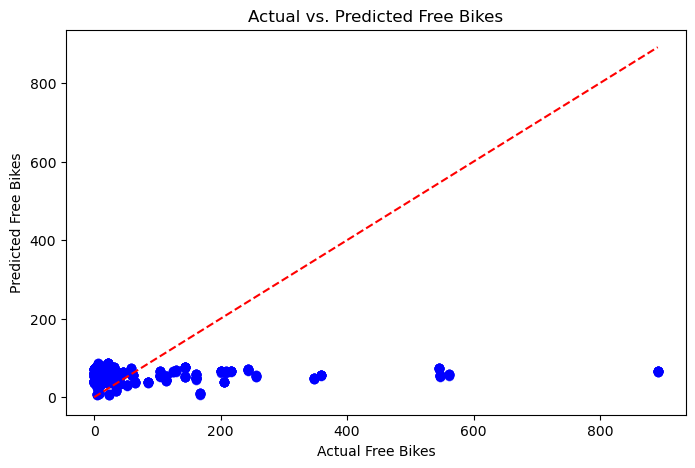

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.xlabel("Actual Free Bikes")
plt.ylabel("Predicted Free Bikes")
plt.title("Actual vs. Predicted Free Bikes")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')  # Perfect Fit Line
plt.show()

# Stretch

How can you turn the regression model into a classification model?